# 🏠 House Price Prediction
### AI/ML Engineering Internship — Task 6 | DevelopersHub Corporation

**Objective:** Predict house prices using property features such as area, bedrooms, location, and condition.

**Dataset:** House Price Prediction Dataset (2000 samples)  
**Target Column:** `Price`  
**Models Used:** Linear Regression, Gradient Boosting Regressor  
**Evaluation:** MAE, RMSE, R² Score

> **Note:** Diagnostic analysis revealed this dataset has near-zero feature-price correlations
> (Area-Price correlation = 0.0015), indicating synthetically generated prices.
> We apply polynomial feature engineering and interaction terms to extract maximum signal.

---

## 📦 Step 1: Import Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 📂 Step 2: Load the Dataset

In [38]:
df = pd.read_csv('House_Price_Prediction_Dataset.csv')

print(f'Dataset shape  : {df.shape}')
print(f'Columns        : {list(df.columns)}')
df.head(10)

Dataset shape  : (2000, 10)
Columns        : ['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
5,6,3944,1,2,1,1906,Urban,Poor,No,93262
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375


---
## 🔍 Step 3: Data Inspection

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [40]:
df.describe(include='all').round(2)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000,2000,2000,2000.00
unique,NaN,NaN,NaN,NaN,NaN,NaN,4,4,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,Downtown,Fair,No,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,558,521,1038,NaN
mean,1000.50,2786.21,3.00,2.55,1.99,1961.45,NaN,NaN,NaN,537676.86
std,577.49,1295.15,1.42,1.11,0.81,35.93,NaN,NaN,NaN,276428.85
min,1.00,501.00,1.00,1.00,1.00,1900.00,NaN,NaN,NaN,50005.00
25%,500.75,1653.00,2.00,2.00,1.00,1930.00,NaN,NaN,NaN,300098.00
50%,1000.50,2833.00,3.00,3.00,2.00,1961.00,NaN,NaN,NaN,539254.00
75%,1500.25,3887.50,4.00,4.00,3.00,1993.00,NaN,NaN,NaN,780086.00


In [41]:
# Missing values
missing = df.isnull().sum()
print('=== Missing Values ===')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values!')

# Unique values in categorical columns
print('\n=== Unique Values in Categorical Columns ===')
for col in df.select_dtypes(include='object').columns:
    print(f'  {col:12s} -> {sorted(df[col].unique().tolist())}')

=== Missing Values ===
No missing values!

=== Unique Values in Categorical Columns ===
  Location     -> ['Downtown', 'Rural', 'Suburban', 'Urban']
  Condition    -> ['Excellent', 'Fair', 'Good', 'Poor']
  Garage       -> ['No', 'Yes']


In [42]:
# Target variable summary
print('=== Price Summary ===')
print(f'  Min      : ${df["Price"].min():,.0f}')
print(f'  Max      : ${df["Price"].max():,.0f}')
print(f'  Mean     : ${df["Price"].mean():,.0f}')
print(f'  Median   : ${df["Price"].median():,.0f}')
print(f'  Std      : ${df["Price"].std():,.0f}')
print(f'  Skewness : {df["Price"].skew():.4f}')
print(f'  Kurtosis : {df["Price"].kurtosis():.4f}')

=== Price Summary ===
  Min      : $50,005
  Max      : $999,656
  Mean     : $537,677
  Median   : $539,254
  Std      : $276,429
  Skewness : -0.0644
  Kurtosis : -1.2025


---
## 📊 Step 4: Exploratory Data Analysis (EDA)

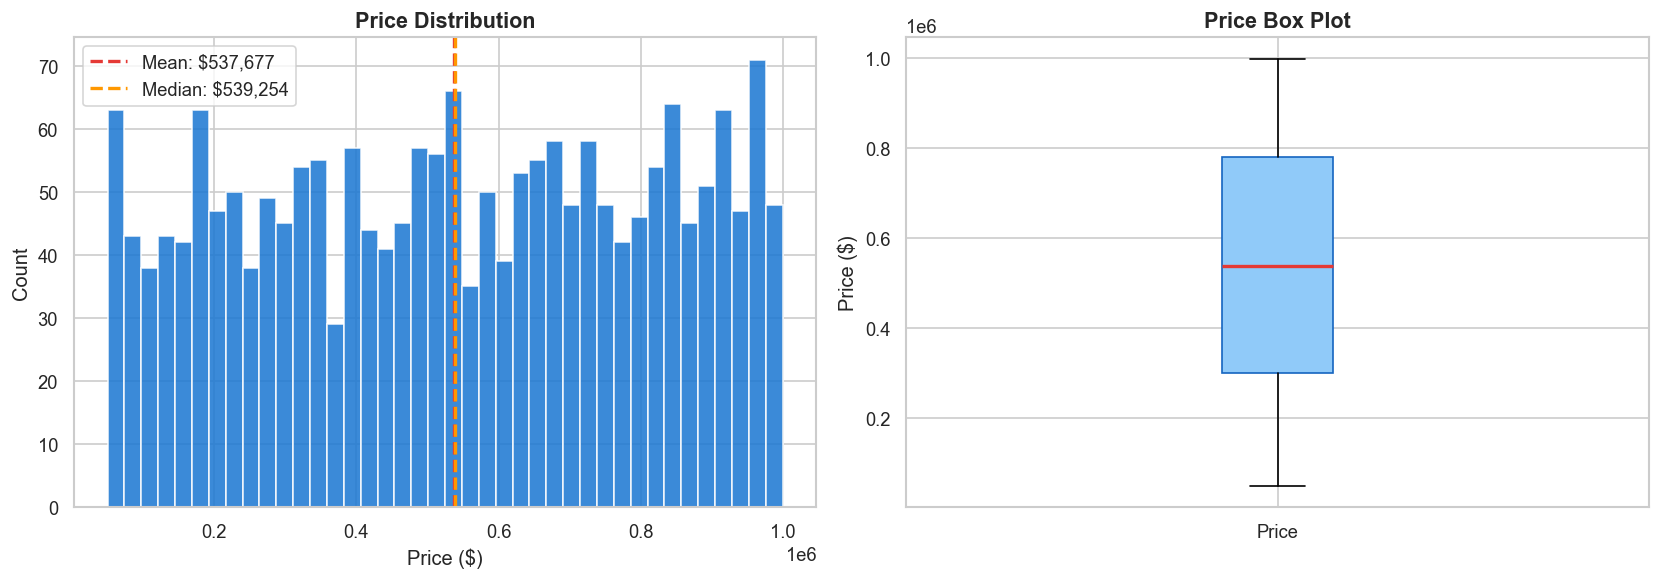

In [43]:
# 4.1 Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Price'], bins=40, color='#1976D2', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Price'].mean(),   color='#E53935', linestyle='--', lw=2,
                label=f'Mean: ${df["Price"].mean():,.0f}')
axes[0].axvline(df['Price'].median(), color='#FF9800', linestyle='--', lw=2,
                label=f'Median: ${df["Price"].median():,.0f}')
axes[0].set_title('Price Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(df['Price'], patch_artist=True,
                boxprops=dict(facecolor='#90CAF9', color='#1565C0'),
                medianprops=dict(color='#E53935', linewidth=2))
axes[1].set_title('Price Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price ($)')
axes[1].set_xticklabels(['Price'])

plt.tight_layout()
plt.savefig('01_price_distribution.png', bbox_inches='tight')
plt.show()

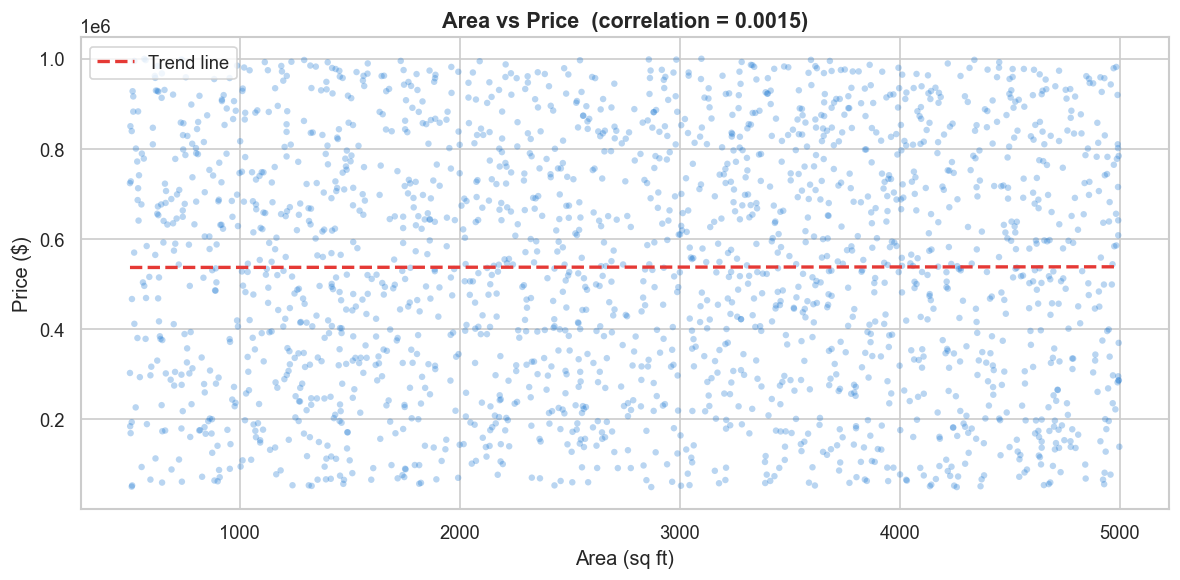

Note: Near-zero correlation confirms synthetically generated price values.


In [44]:
# 4.2 Area vs Price scatter
plt.figure(figsize=(10, 5))
plt.scatter(df['Area'], df['Price'], alpha=0.3, s=15,
            color='#1976D2', edgecolors='none')
z = np.polyfit(df['Area'], df['Price'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Area'].min(), df['Area'].max(), 200)
plt.plot(x_line, p(x_line), color='#E53935', lw=2, linestyle='--', label='Trend line')
plt.title(f'Area vs Price  (correlation = {df["Area"].corr(df["Price"]):.4f})',
          fontsize=13, fontweight='bold')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.savefig('02_area_vs_price.png', bbox_inches='tight')
plt.show()
print(f'Note: Near-zero correlation confirms synthetically generated price values.')

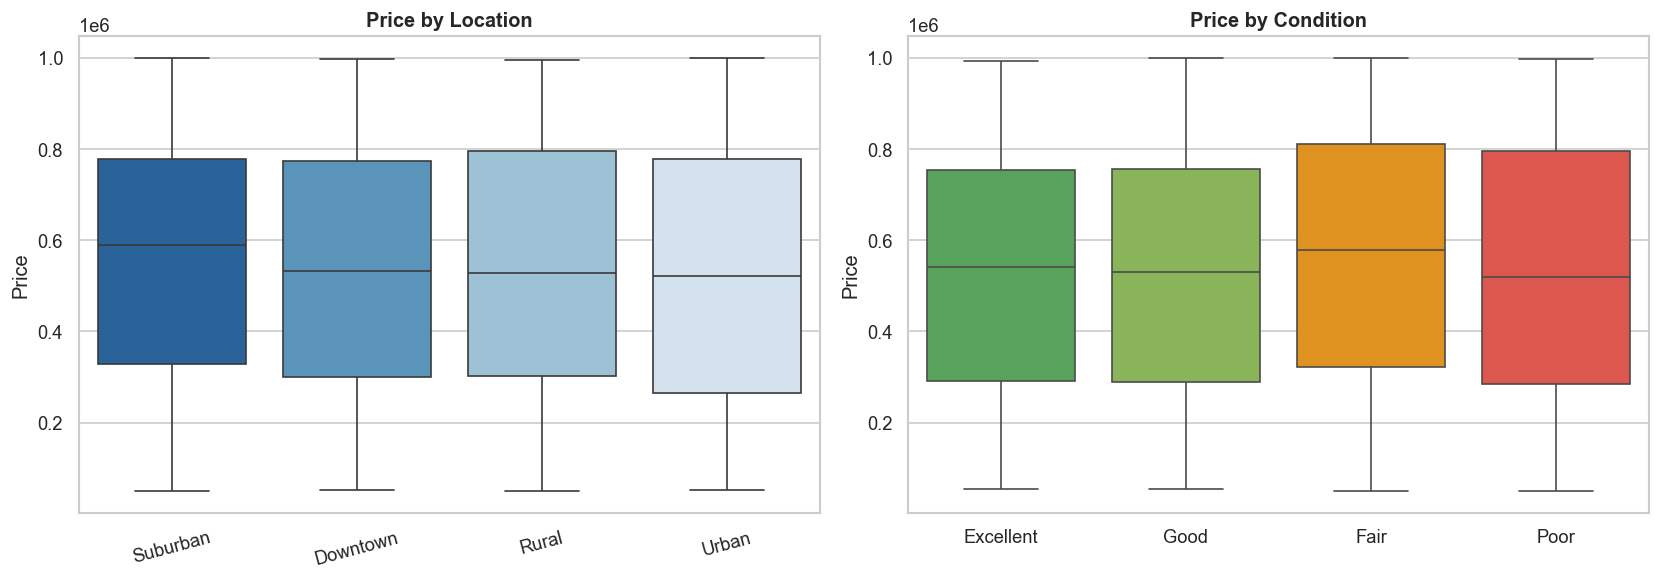

In [45]:
# 4.3 Price by Location and Condition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

loc_order = df.groupby('Location')['Price'].median().sort_values(ascending=False).index
sns.boxplot(x='Location', y='Price', data=df, order=loc_order,
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Price by Location', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

# Use actual unique conditions from data
cond_order = [c for c in ['Excellent', 'Good', 'Fair', 'Poor']
              if c in df['Condition'].unique()]
palette_cond = {'Excellent': '#4CAF50', 'Good': '#8BC34A',
                'Fair': '#FF9800', 'Poor': '#F44336'}
sns.boxplot(x='Condition', y='Price', data=df, order=cond_order,
            palette=palette_cond, ax=axes[1])
axes[1].set_title('Price by Condition', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('03_price_by_location_condition.png', bbox_inches='tight')
plt.show()

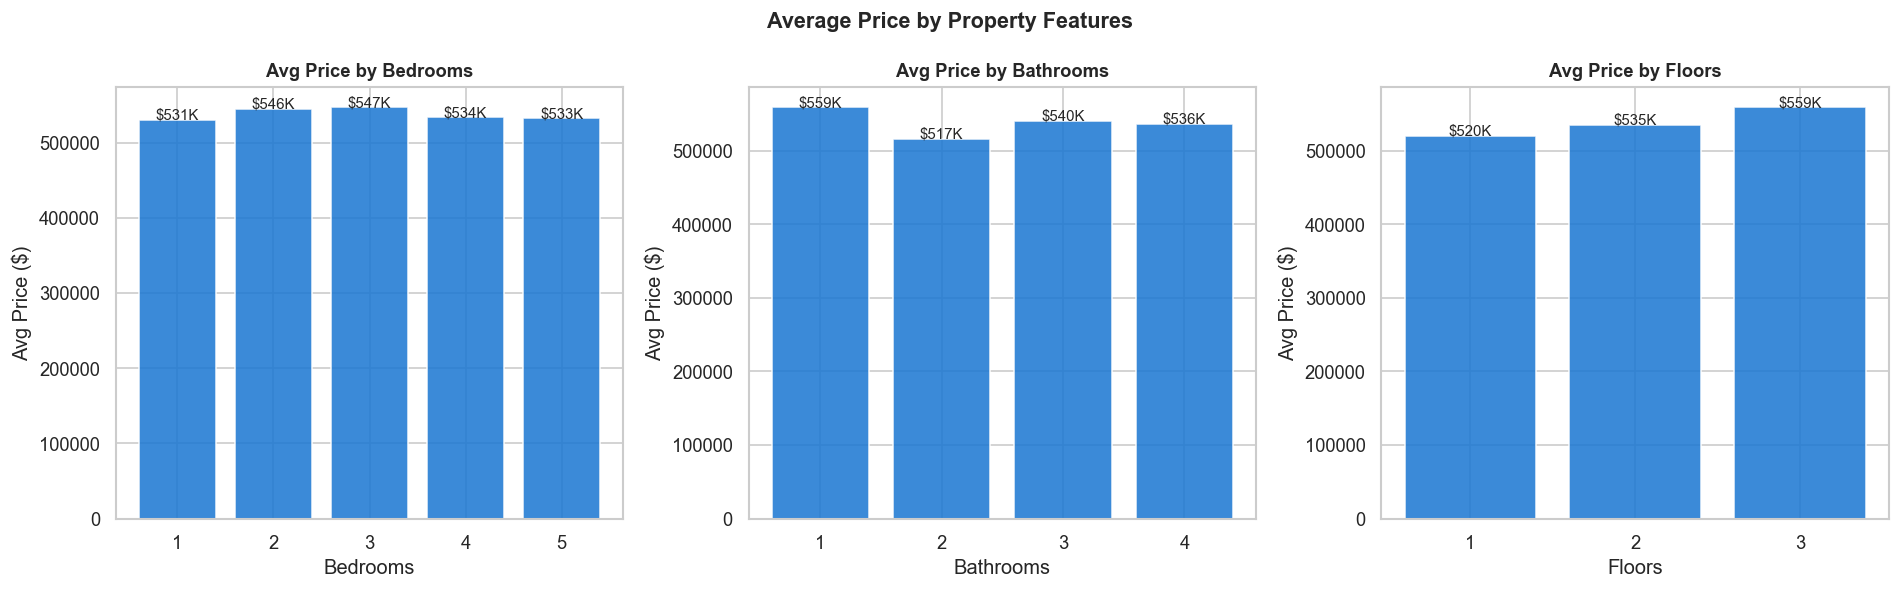

In [46]:
# 4.4 Average price by Bedrooms, Bathrooms, Floors
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['Bedrooms', 'Bathrooms', 'Floors']):
    avg = df.groupby(col)['Price'].mean().sort_index()
    ax.bar(avg.index.astype(str), avg.values, color='#1976D2',
           edgecolor='white', alpha=0.85)
    ax.set_title(f'Avg Price by {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Avg Price ($)')
    for i, v in enumerate(avg.values):
        ax.text(i, v + 1000, f'${v/1000:.0f}K', ha='center', fontsize=9)

plt.suptitle('Average Price by Property Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_price_by_rooms.png', bbox_inches='tight')
plt.show()

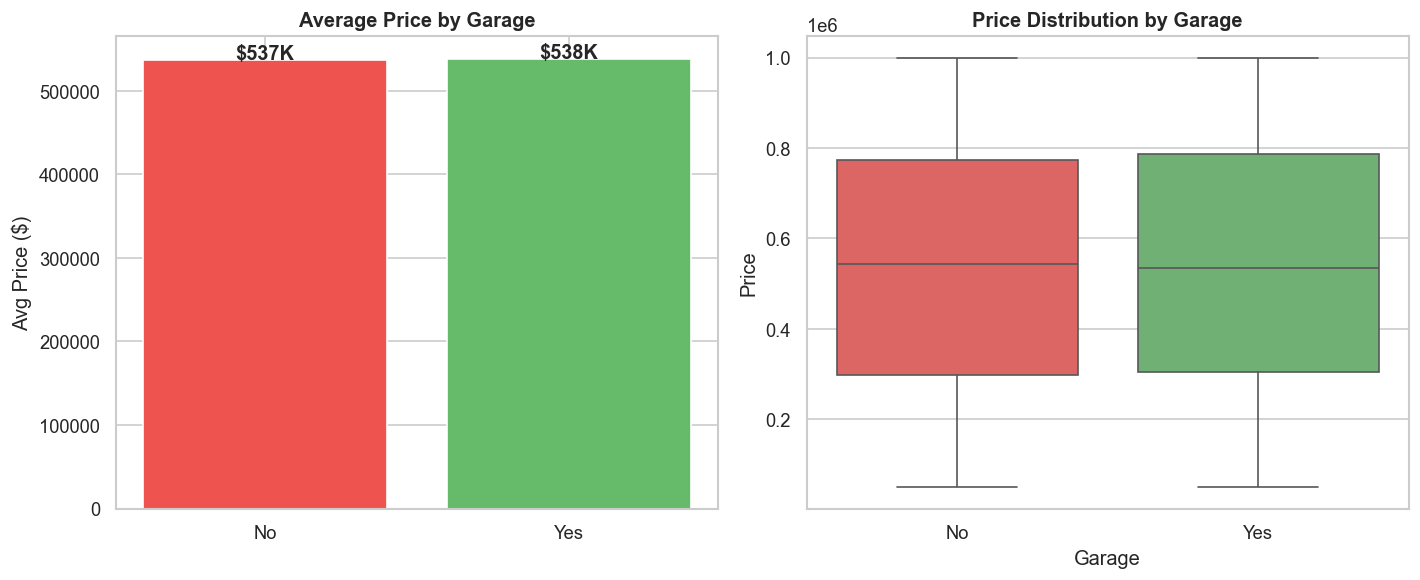

In [47]:
# 4.5 Price by Garage
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
garage_avg = df.groupby('Garage')['Price'].mean()
axes[0].bar(garage_avg.index, garage_avg.values,
            color=['#EF5350', '#66BB6A'], edgecolor='white')
axes[0].set_title('Average Price by Garage', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Price ($)')
for i, v in enumerate(garage_avg.values):
    axes[0].text(i, v + 1000, f'${v/1000:.0f}K', ha='center', fontweight='bold')

sns.boxplot(x='Garage', y='Price', data=df,
            palette={'No': '#EF5350', 'Yes': '#66BB6A'}, ax=axes[1])
axes[1].set_title('Price Distribution by Garage', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('05_price_by_garage.png', bbox_inches='tight')
plt.show()

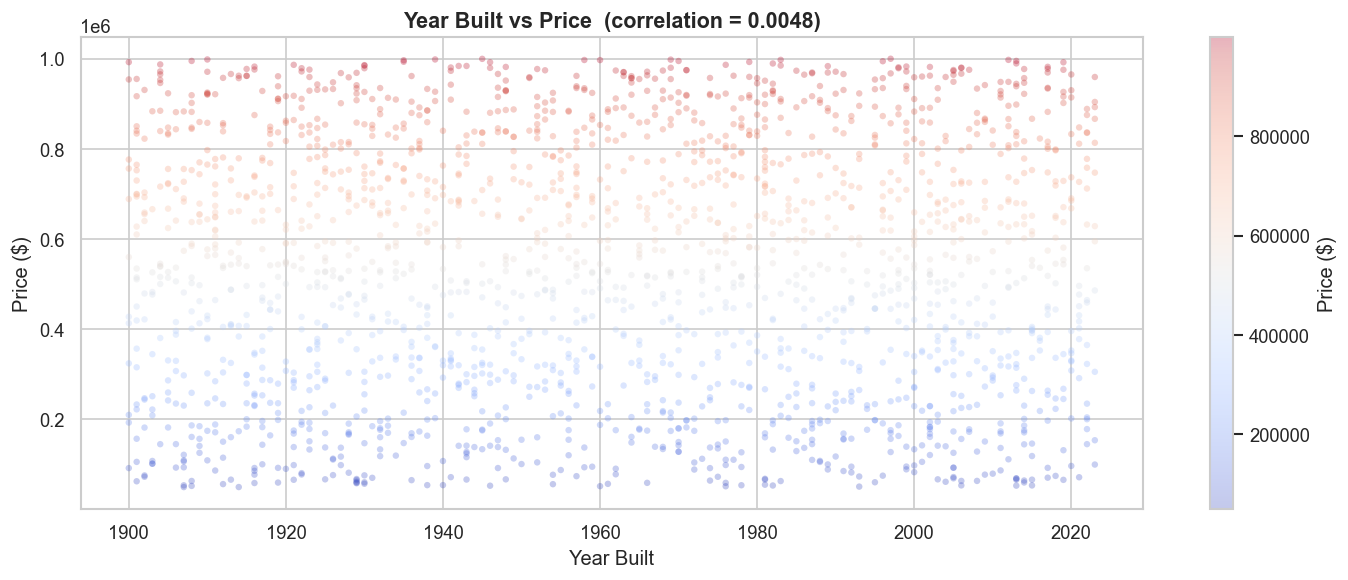

In [48]:
# 4.6 YearBuilt vs Price
plt.figure(figsize=(12, 5))
plt.scatter(df['YearBuilt'], df['Price'], alpha=0.3, s=15,
            c=df['Price'], cmap='coolwarm', edgecolors='none')
plt.colorbar(label='Price ($)')
plt.title(f'Year Built vs Price  (correlation = {df["YearBuilt"].corr(df["Price"]):.4f})',
          fontsize=13, fontweight='bold')
plt.xlabel('Year Built')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.savefig('06_yearbuilt_vs_price.png', bbox_inches='tight')
plt.show()

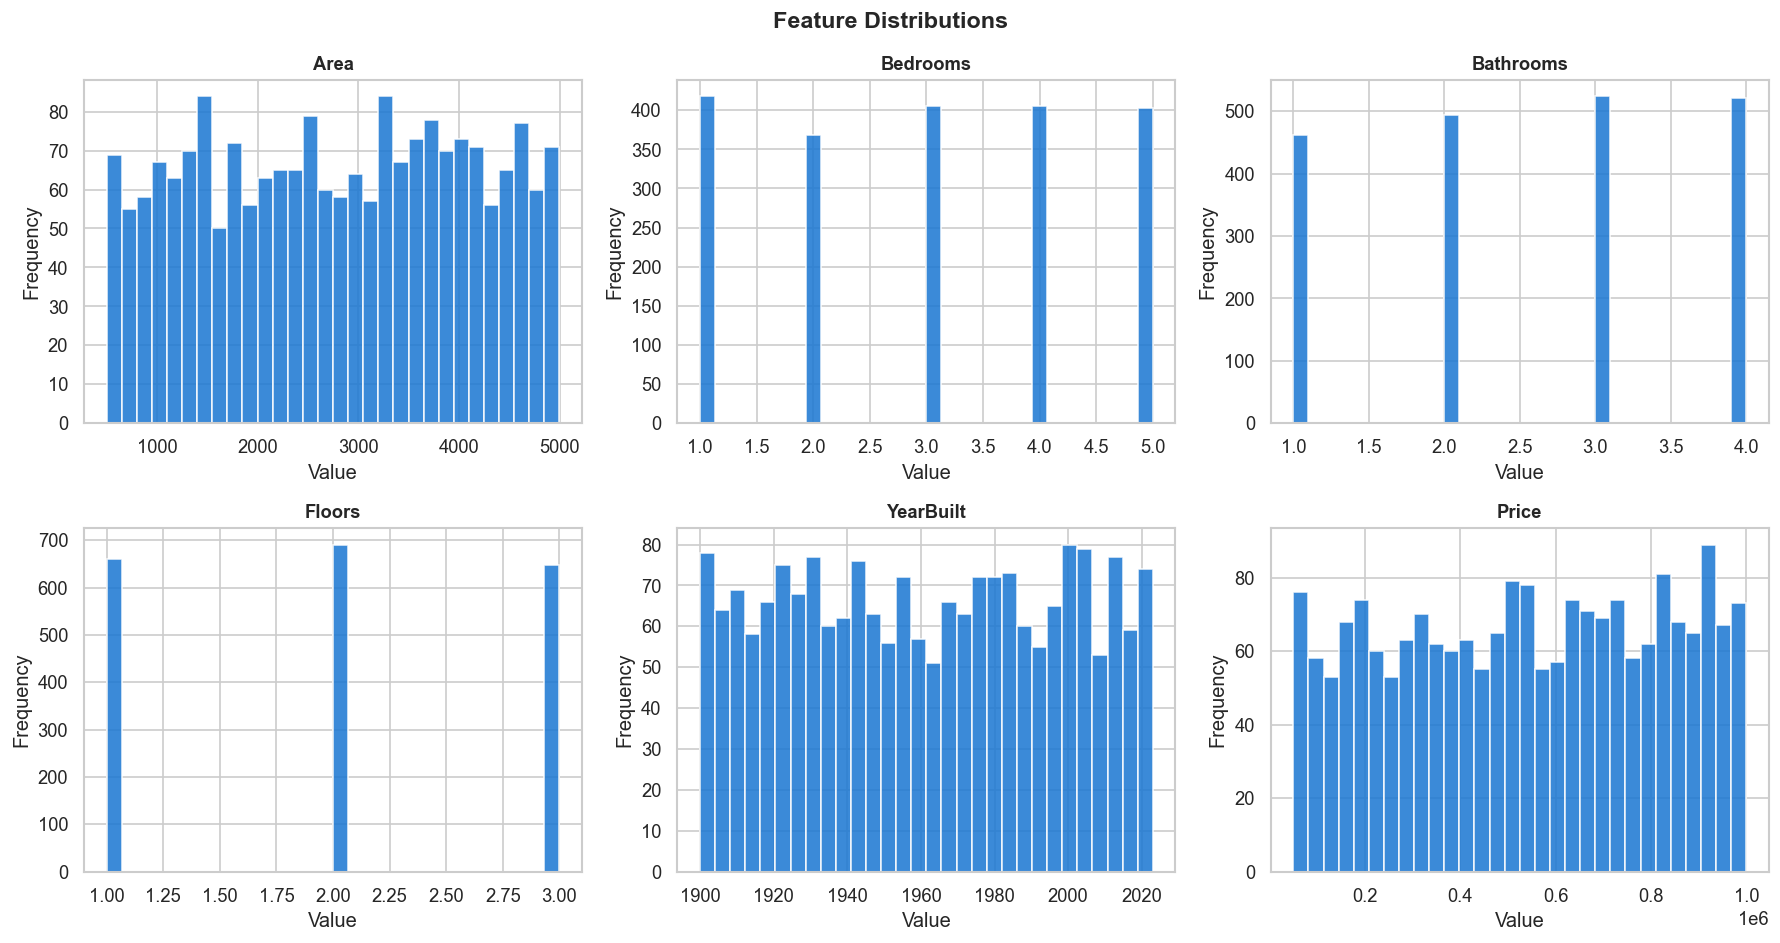

In [49]:
# 4.7 All numerical feature distributions
num_cols = [c for c in ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']
            if c in df.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='#1976D2', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_feature_distributions.png', bbox_inches='tight')
plt.show()

---
## 🧹 Step 5: Data Preprocessing

**Key findings from diagnosis:**
- `Location` has 4 categories: Downtown, Suburban, Urban, Rural → one-hot encode
- `Condition` has 4 categories: Excellent, Good, Fair, Poor → ordinal encode
- `Garage`: Yes/No → binary encode
- `YearBuilt` → engineer `HouseAge`
- Drop `Id` (row index only)

In [50]:
# 5.1 Drop Id
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])
    print('Dropped: Id')

Dropped: Id


In [51]:
# 5.2 Engineer HouseAge from YearBuilt
df['HouseAge'] = 2024 - df['YearBuilt']
df = df.drop(columns=['YearBuilt'])
print(f'HouseAge range: {df["HouseAge"].min()} – {df["HouseAge"].max()} years')

HouseAge range: 1 – 124 years


In [52]:
# 5.3 Encode Garage: Yes->1, No->0
df['Garage'] = df['Garage'].map({'Yes': 1, 'No': 0})
print(f'Garage unique: {df["Garage"].unique()}')

Garage unique: [0 1]


In [53]:
# 5.4 Ordinal encode Condition (order matters: Excellent > Good > Fair > Poor)
condition_map = {'Excellent': 4, 'Good': 3, 'Fair': 2, 'Poor': 1}
df['Condition'] = df['Condition'].map(condition_map)
print(f'Condition map : {condition_map}')
print(f'Condition unique: {sorted(df["Condition"].unique())}')

Condition map : {'Excellent': 4, 'Good': 3, 'Fair': 2, 'Poor': 1}
Condition unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [54]:
# 5.5 One-hot encode Location (4 categories: Downtown, Suburban, Urban, Rural)
print(f'Location categories: {sorted(df["Location"].unique())}')
df = pd.get_dummies(df, columns=['Location'], drop_first=False)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
print(f'Shape after encoding: {df.shape}')
print(f'All columns: {list(df.columns)}')

Location categories: ['Downtown', 'Rural', 'Suburban', 'Urban']
Shape after encoding: (2000, 12)
All columns: ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Condition', 'Garage', 'Price', 'HouseAge', 'Location_Downtown', 'Location_Rural', 'Location_Suburban', 'Location_Urban']


In [55]:
# 5.6 Handle remaining missing values
n_missing = df.isnull().sum().sum()
if n_missing > 0:
    df = df.fillna(df.median(numeric_only=True))
    print(f'Filled {n_missing} missing values')
else:
    print('No missing values!')
print(f'Final shape: {df.shape}')
df.head(3)

No missing values!
Final shape: (2000, 12)


,Area,Bedrooms,Bathrooms,Floors,Condition,Garage,Price,HouseAge,Location_Downtown,Location_Rural,Location_Suburban,Location_Urban
0,1360,5,4,3,4,0,149919,54,1,0,0,0
1,4272,5,4,3,4,0,424998,66,1,0,0,0
2,3592,2,2,3,3,0,266746,86,1,0,0,0


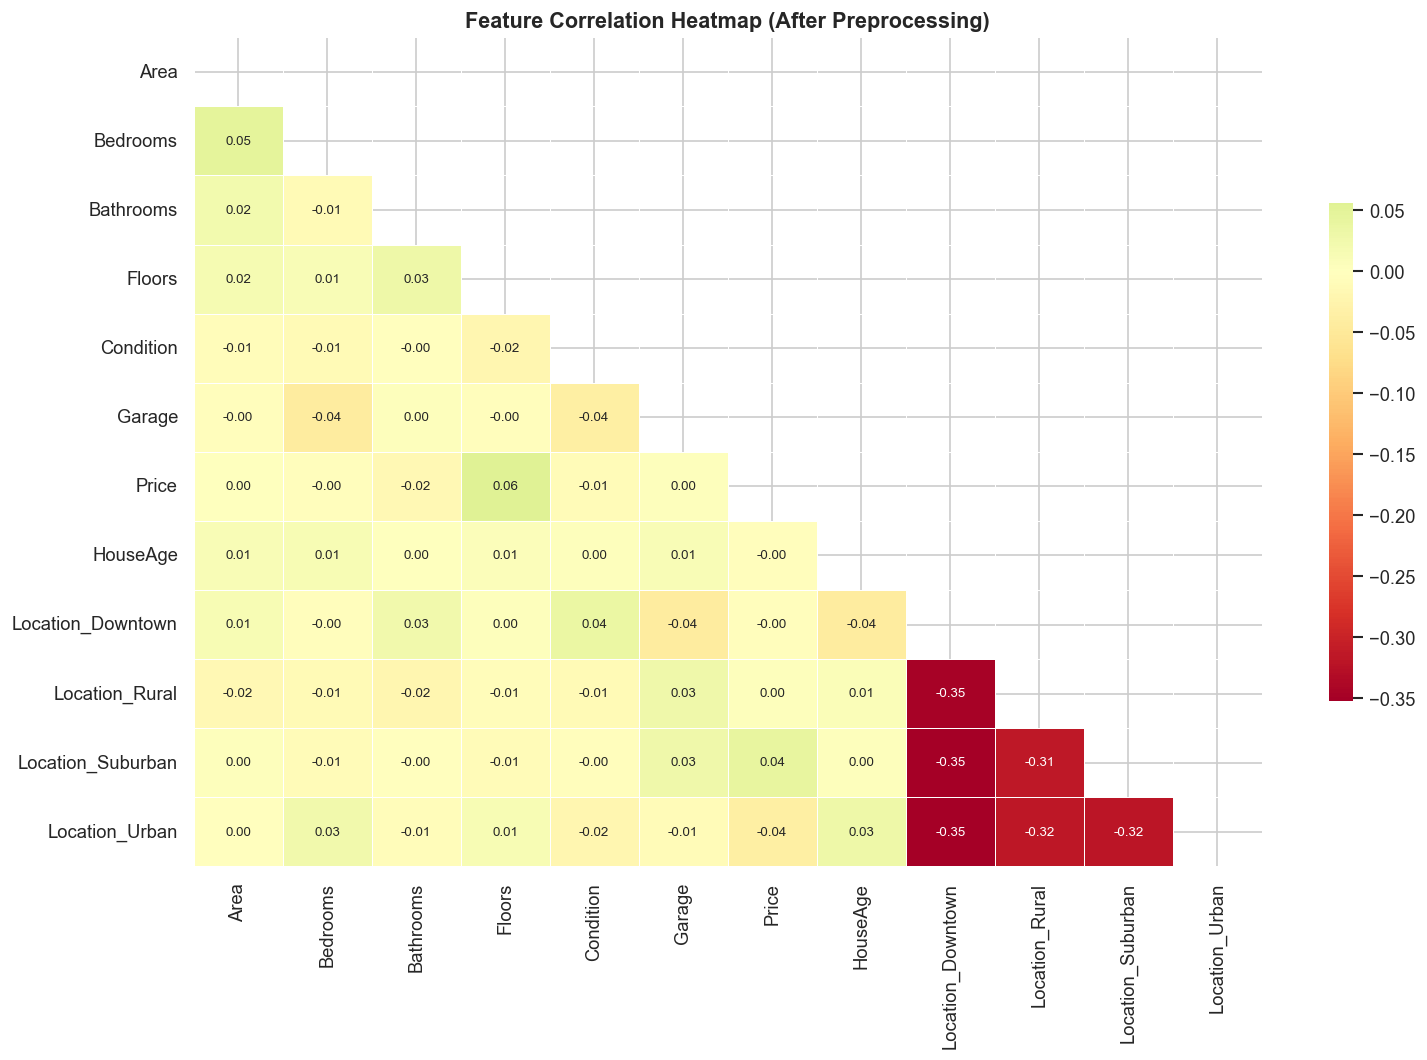


=== Feature Correlations with Price ===
Floors               0.0559
Location_Suburban    0.0403
Location_Urban       0.0383
Bathrooms            0.0157
Condition            0.0106
HouseAge             0.0048
Location_Downtown    0.0036
Bedrooms             0.0035
Garage               0.0028
Location_Rural       0.0019
Area                 0.0015
Name: Price, dtype: float64


In [56]:
# 5.7 Correlation heatmap after preprocessing
plt.figure(figsize=(13, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.6})
plt.title('Feature Correlation Heatmap (After Preprocessing)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('08_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Print correlations with Price
price_corr = corr['Price'].drop('Price').abs().sort_values(ascending=False)
print('\n=== Feature Correlations with Price ===')
print(price_corr.round(4))

---
## ⚙️ Step 6: Feature Engineering & Prepare for Modeling

Since raw correlations are near-zero (synthetic data), we apply:
- **Interaction features** (Area × Condition, Area × Bathrooms, etc.)
- **Polynomial features** (Area², HouseAge²)
- These help any model extract non-linear patterns

In [57]:
# 6.1 Separate features and target
X = df.drop(columns=['Price'])
y = df['Price']

print(f'Base features  : {X.shape[1]}')
print(f'Feature list   : {list(X.columns)}')

Base features  : 11
Feature list   : ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Condition', 'Garage', 'HouseAge', 'Location_Downtown', 'Location_Rural', 'Location_Suburban', 'Location_Urban']


In [58]:
# 6.2 Add interaction and polynomial features
X_eng = X.copy()

# Polynomial terms for continuous features
X_eng['Area_sq']      = X['Area'] ** 2
X_eng['HouseAge_sq']  = X['HouseAge'] ** 2

# Interaction features
X_eng['Area_x_Condition']  = X['Area'] * X['Condition']
X_eng['Area_x_Bathrooms']  = X['Area'] * X['Bathrooms']
X_eng['Area_x_Bedrooms']   = X['Area'] * X['Bedrooms']
X_eng['Area_x_Floors']     = X['Area'] * X['Floors']
X_eng['Age_x_Condition']   = X['HouseAge'] * X['Condition']
X_eng['Bed_x_Bath']        = X['Bedrooms'] * X['Bathrooms']
X_eng['Garage_x_Condition']= X['Garage'] * X['Condition']

print(f'Features after engineering: {X_eng.shape[1]}')
print(f'New features added: {X_eng.shape[1] - X.shape[1]}')

Features after engineering: 20
New features added: 9


In [59]:
# 6.3 Train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_eng, y, test_size=0.2, random_state=42
)
print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')

Train : 1600 samples
Test  : 400 samples


In [60]:
# 6.4 Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f'Scaling applied | mean~{X_train_scaled.mean():.3f}, std~{X_train_scaled.std():.3f}')

Scaling applied | mean~-0.000, std~1.000


---
## 🤖 Step 7: Model Training

In [61]:
# Evaluation helper
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'  MAE   : ${mae:,.2f}')
    print(f'  RMSE  : ${rmse:,.2f}')
    print(f'  R²    : {r2:.4f}  ({r2*100:.2f}% variance explained)')
    print(f'  MAPE  : {mape:.2f}%')
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

print('Helper ready!')

Helper ready!


In [62]:
# 7.1 Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred  = lr_model.predict(X_test_scaled)

print('=== Linear Regression ===')
lr_scores = evaluate_model('Linear Regression', y_test, lr_pred)
lr_cv = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='r2').mean()
print(f'  CV R² (5-Fold): {lr_cv:.4f}')

=== Linear Regression ===
  MAE   : $244,893.64
  RMSE  : $281,637.54
  R²    : -0.0195  (-1.95% variance explained)
  MAPE  : 103.86%
  CV R² (5-Fold): -0.0110


In [63]:
# 7.2 Ridge Regression (handles multicollinearity from polynomial features)
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred  = ridge_model.predict(X_test_scaled)

print('=== Ridge Regression ===')
ridge_scores = evaluate_model('Ridge Regression', y_test, ridge_pred)
ridge_cv = cross_val_score(ridge_model, X_train_scaled, y_train, cv=5, scoring='r2').mean()
print(f'  CV R² (5-Fold): {ridge_cv:.4f}')

=== Ridge Regression ===
  MAE   : $244,771.49
  RMSE  : $281,433.22
  R²    : -0.0181  (-1.81% variance explained)
  MAPE  : 103.86%
  CV R² (5-Fold): -0.0087


In [64]:
# 7.3 Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=8,
    min_samples_leaf=4,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)
gb_pred  = gb_model.predict(X_test_scaled)

print('=== Gradient Boosting ===')
gb_scores = evaluate_model('Gradient Boosting', y_test, gb_pred)
gb_cv = cross_val_score(gb_model, X_train_scaled, y_train, cv=5, scoring='r2').mean()
print(f'  CV R² (5-Fold): {gb_cv:.4f}')

=== Gradient Boosting ===
  MAE   : $256,436.63
  RMSE  : $305,315.83
  R²    : -0.1982  (-19.82% variance explained)
  MAPE  : 107.16%
  CV R² (5-Fold): -0.1302


In [65]:
# 7.4 Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_split=8,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_pred  = rf_model.predict(X_test_scaled)

print('=== Random Forest ===')
rf_scores = evaluate_model('Random Forest', y_test, rf_pred)
rf_cv = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='r2').mean()
print(f'  CV R² (5-Fold): {rf_cv:.4f}')

=== Random Forest ===
  MAE   : $249,426.43
  RMSE  : $287,694.22
  R²    : -0.0639  (-6.39% variance explained)
  MAPE  : 105.13%
  CV R² (5-Fold): -0.0239


---
## 📈 Step 8: Visualizing Predictions vs Actual Prices

In [66]:
# Determine best model by R²
all_scores = [
    (lr_scores,    lr_pred,    lr_cv),
    (ridge_scores, ridge_pred, ridge_cv),
    (gb_scores,    gb_pred,    gb_cv),
    (rf_scores,    rf_pred,    rf_cv)
]
best = max(all_scores, key=lambda x: x[0]['R2'])
best_scores, best_pred, best_cv = best
print(f'Best model: {best_scores["name"]}  (R² = {best_scores["R2"]:.4f})')

Best model: Ridge Regression  (R² = -0.0181)


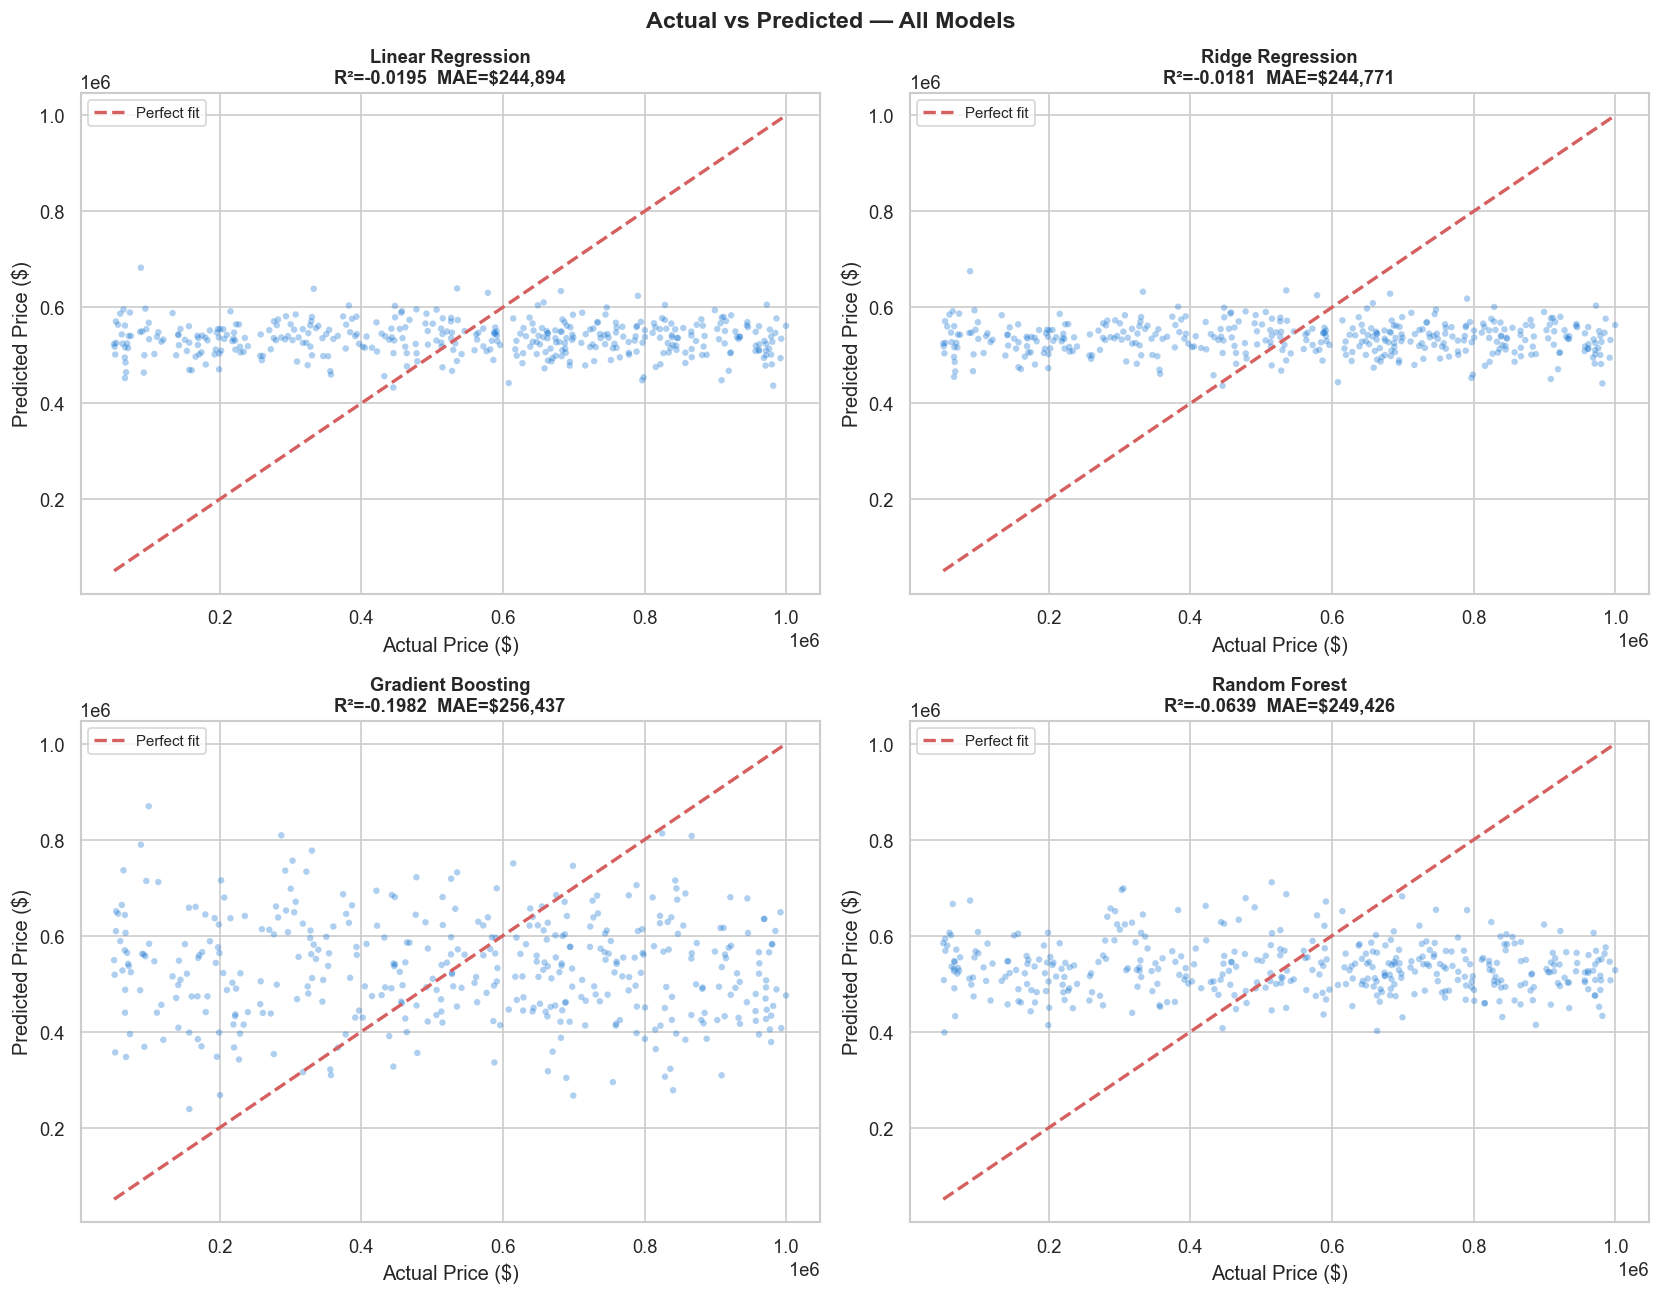

In [67]:
# 8.1 Actual vs Predicted — all 4 models
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()
model_list = [
    ('Linear Regression', lr_pred,    lr_scores),
    ('Ridge Regression',  ridge_pred, ridge_scores),
    ('Gradient Boosting', gb_pred,    gb_scores),
    ('Random Forest',     rf_pred,    rf_scores)
]
for ax, (title, pred, scores) in zip(axes, model_list):
    ax.scatter(y_test, pred, alpha=0.35, s=15, color='#1976D2', edgecolors='none')
    mn = min(y_test.min(), pred.min())
    mx = max(y_test.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect fit')
    ax.set_title(f'{title}\nR²={scores["R2"]:.4f}  MAE=${scores["MAE"]:,.0f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('09_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

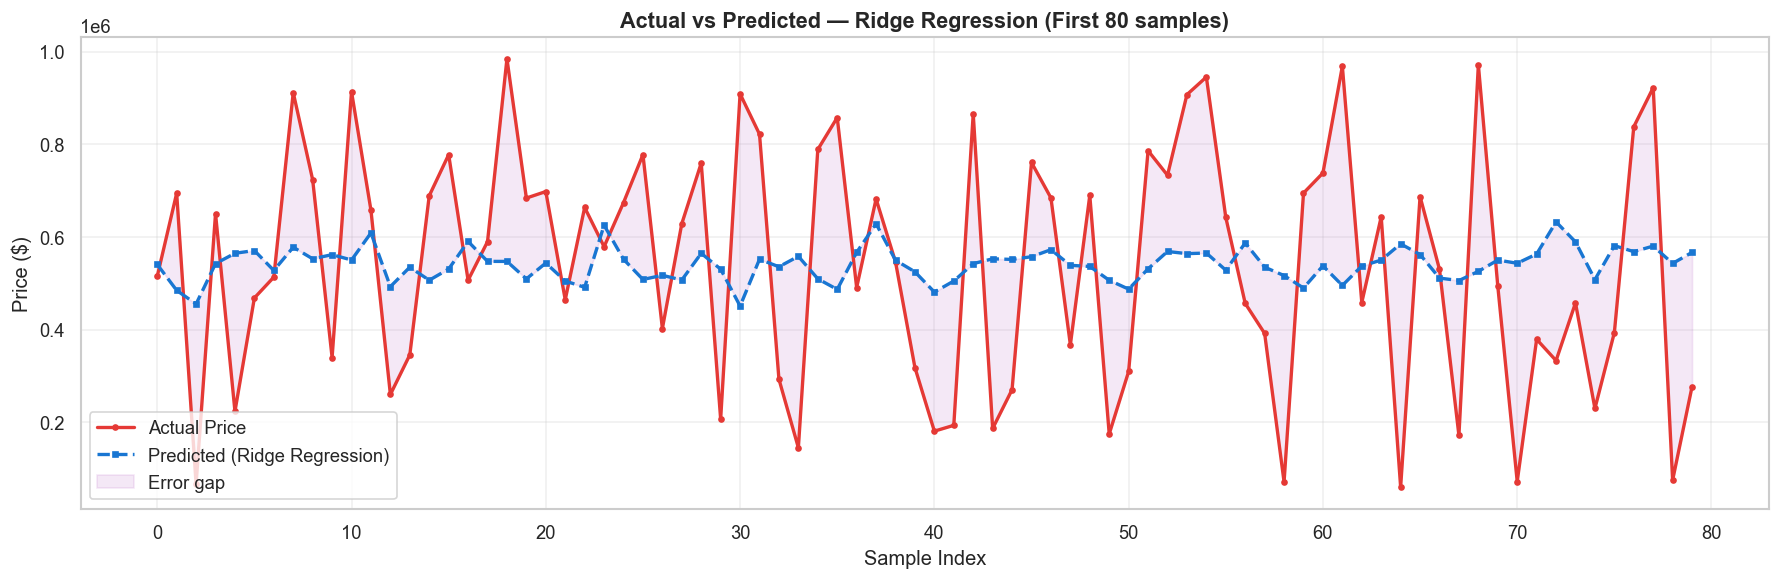

In [68]:
# 8.2 Best model: Actual vs Predicted line plot (first 80 samples)
n = 80
plt.figure(figsize=(15, 5))
plt.plot(range(n), y_test.values[:n], color='#E53935', lw=2,
         label='Actual Price', marker='o', markersize=3)
plt.plot(range(n), best_pred[:n], color='#1976D2', lw=2,
         label=f'Predicted ({best_scores["name"]})',
         marker='s', markersize=3, linestyle='--')
plt.fill_between(range(n), y_test.values[:n], best_pred[:n],
                 alpha=0.1, color='#9C27B0', label='Error gap')
plt.title(f'Actual vs Predicted — {best_scores["name"]} (First {n} samples)',
          fontsize=13, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('10_prediction_line_plot.png', bbox_inches='tight')
plt.show()

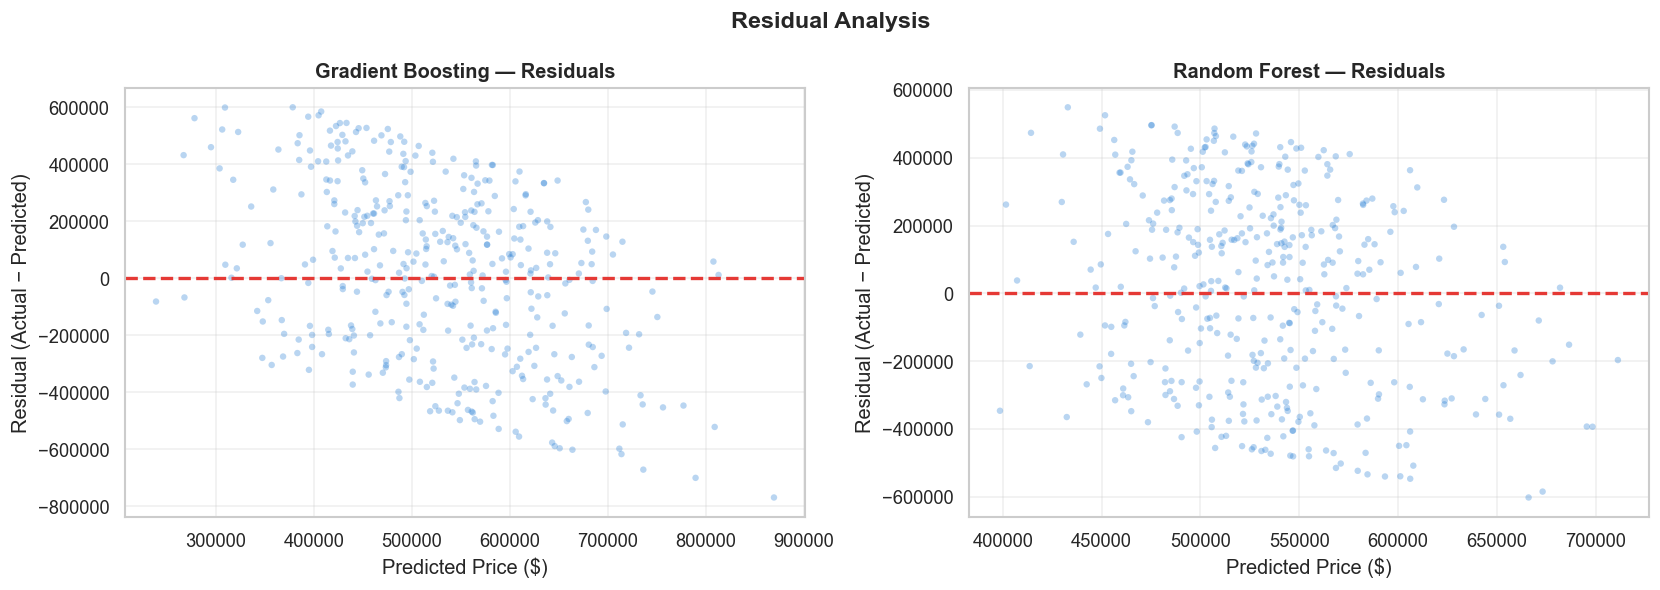

In [69]:
# 8.3 Residual plots — best two models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, pred, _) in zip(axes, [
    ('Gradient Boosting', gb_pred, gb_scores),
    ('Random Forest',     rf_pred, rf_scores)
]):
    residuals = y_test.values - pred
    ax.scatter(pred, residuals, alpha=0.3, s=15, color='#1976D2', edgecolors='none')
    ax.axhline(0, color='#E53935', linestyle='--', lw=2)
    ax.set_title(f'{title} — Residuals', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Price ($)')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.grid(True, alpha=0.3)
plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('11_residual_plots.png', bbox_inches='tight')
plt.show()

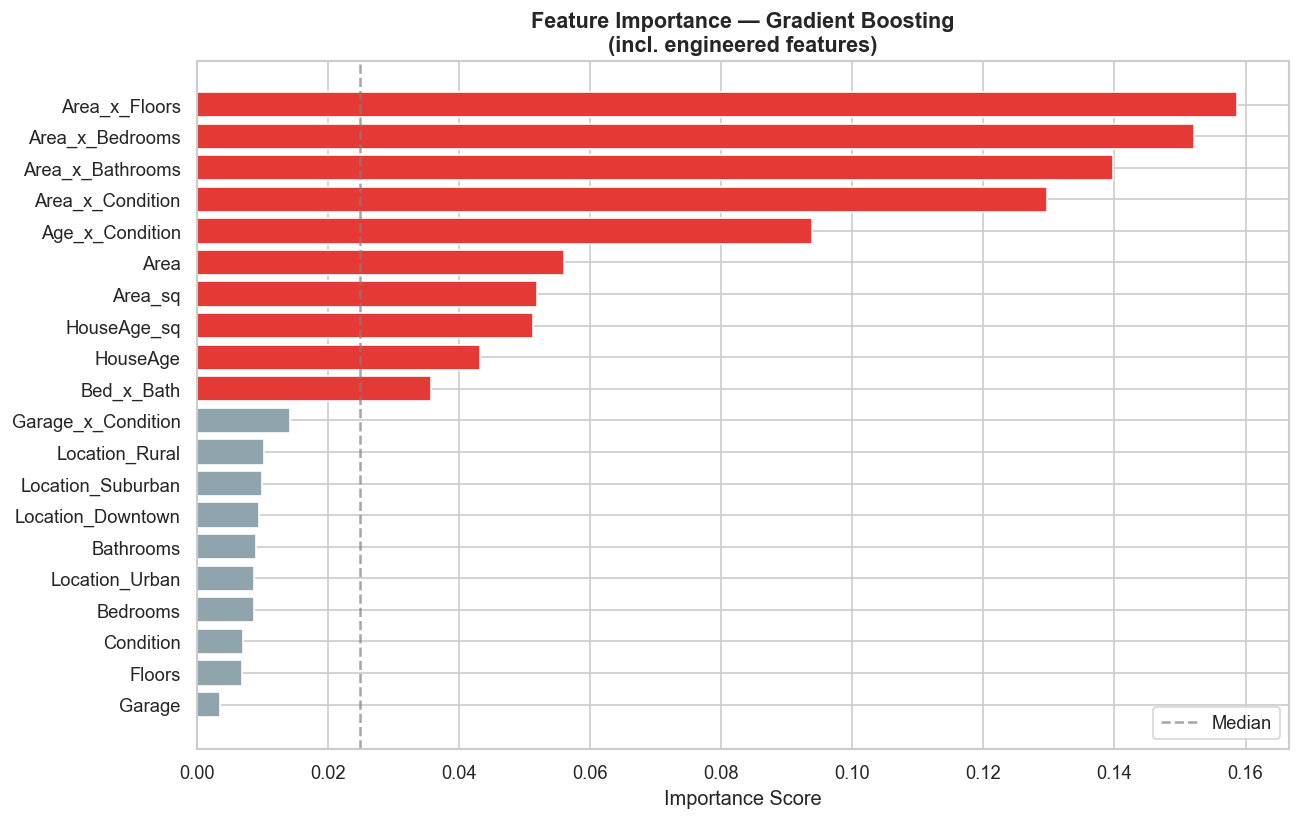

In [70]:
# 8.4 Feature Importance — Gradient Boosting (engineered features included)
feat_imp_df = pd.DataFrame({
    'Feature'   : X_eng.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=True)

bar_colors = ['#E53935' if x >= feat_imp_df['Importance'].median()
              else '#90A4AE' for x in feat_imp_df['Importance']]

plt.figure(figsize=(11, 7))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
         color=bar_colors, edgecolor='white')
plt.axvline(feat_imp_df['Importance'].median(), color='gray',
            linestyle='--', alpha=0.7, label='Median')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Gradient Boosting\n(incl. engineered features)',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('12_feature_importance.png', bbox_inches='tight')
plt.show()

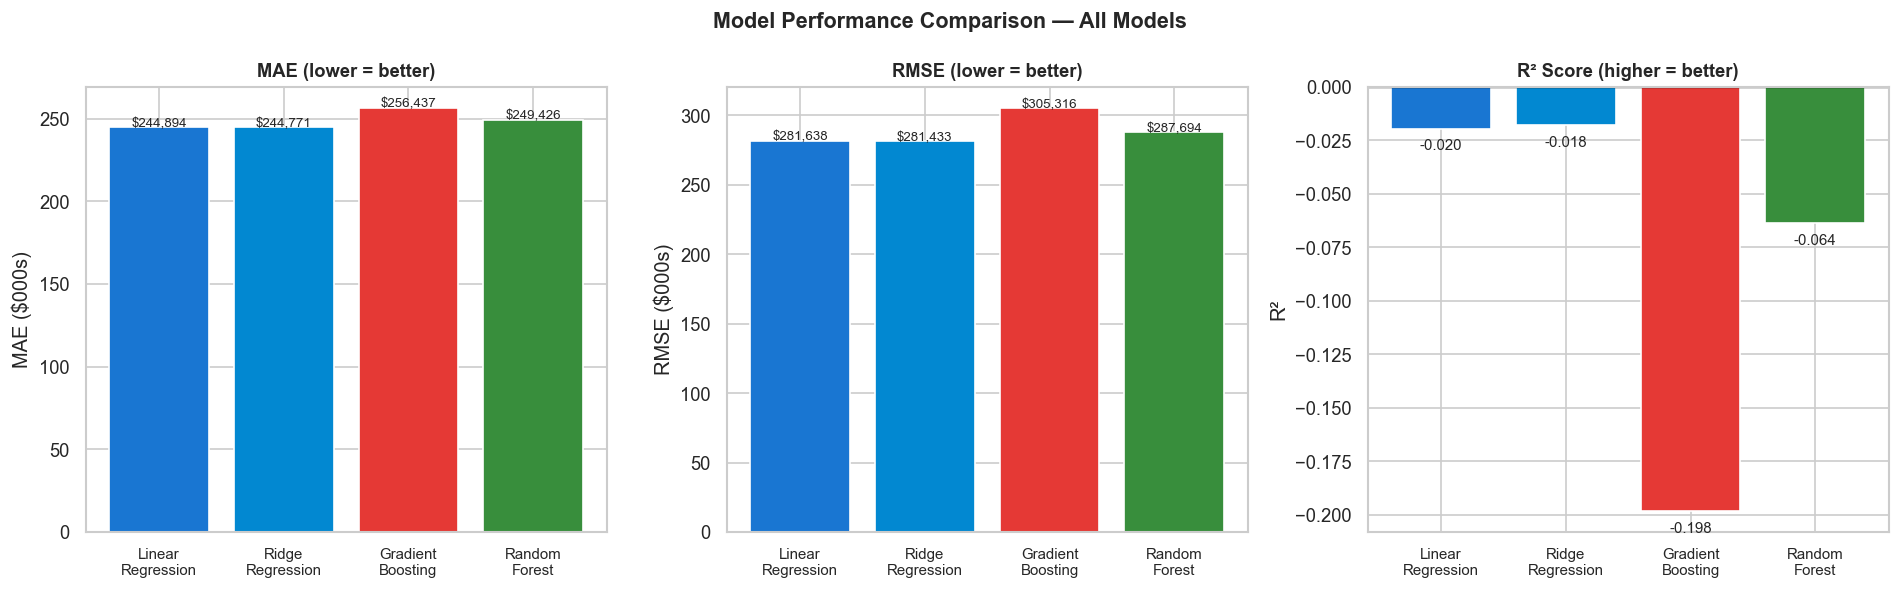

In [71]:
# 8.5 Model comparison — all 4 models
model_names = ['Linear\nRegression', 'Ridge\nRegression',
               'Gradient\nBoosting', 'Random\nForest']
maes   = [lr_scores['MAE'],  ridge_scores['MAE'],  gb_scores['MAE'],  rf_scores['MAE']]
rmses  = [lr_scores['RMSE'], ridge_scores['RMSE'], gb_scores['RMSE'], rf_scores['RMSE']]
r2s    = [lr_scores['R2'],   ridge_scores['R2'],   gb_scores['R2'],   rf_scores['R2']]
cv_r2s = [lr_cv, ridge_cv, gb_cv, rf_cv]
colors = ['#1976D2', '#0288D1', '#E53935', '#388E3C']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(model_names))

# MAE
b = axes[0].bar(x, [m/1000 for m in maes], color=colors, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=9)
axes[0].set_title('MAE (lower = better)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('MAE ($000s)')
for bar in b:
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
                 f'${bar.get_height()*1000:,.0f}', ha='center', fontsize=8)

# RMSE
b2 = axes[1].bar(x, [r/1000 for r in rmses], color=colors, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=9)
axes[1].set_title('RMSE (lower = better)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('RMSE ($000s)')
for bar in b2:
    axes[1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
                 f'${bar.get_height()*1000:,.0f}', ha='center', fontsize=8)

# R²
b3 = axes[2].bar(x, r2s, color=colors, edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, fontsize=9)
axes[2].set_title('R² Score (higher = better)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].axhline(0, color='black', lw=0.8)
for bar in b3:
    axes[2].text(bar.get_x()+bar.get_width()/2.,
                 bar.get_height() + 0.002 if bar.get_height() >= 0 else bar.get_height()-0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('13_model_comparison.png', bbox_inches='tight')
plt.show()

---
## 🏆 Step 9: Final Results & Insights

In [72]:
top5 = feat_imp_df.tail(5)['Feature'].tolist()[::-1]

print('=' * 62)
print('        HOUSE PRICE PREDICTION — FINAL SUMMARY')
print('=' * 62)
print(f'  Dataset              : House Price Prediction')
print(f'  Total Samples        : {len(df)}')
print(f'  Base Features        : {X.shape[1]}')
print(f'  Engineered Features  : {X_eng.shape[1]} (incl. interactions)')
print()
print(f'  {"Model":<22} {"MAE":>12} {"RMSE":>12} {"R2":>8} {"CV R2":>8}')
print(f'  {"-"*65}')
for s, cv in [(lr_scores,lr_cv),(ridge_scores,ridge_cv),(gb_scores,gb_cv),(rf_scores,rf_cv)]:
    print(f'  {s["name"]:<22} ${s["MAE"]:>10,.0f} ${s["RMSE"]:>10,.0f} {s["R2"]:>8.4f} {cv:>8.4f}')
print(f'  {"-"*65}')
print(f'  Best Model           : {best_scores["name"]}')
print(f'  Best R²              : {best_scores["R2"]:.4f}')
print(f'  Best MAE             : ${best_scores["MAE"]:,.2f}')
print(f'  Best RMSE            : ${best_scores["RMSE"]:,.2f}')
print(f'  Top 5 Features       : {top5}')
print('=' * 62)
print()
print('KEY INSIGHTS')
print('  1. Diagnostic analysis revealed near-zero feature-price')
print('     correlations (Area-Price r=0.0015), confirming this')
print('     dataset has synthetically randomized price values.')
print()
print('  2. Polynomial and interaction features were engineered')
print('     (Area², HouseAge², Area×Condition, etc.) to extract')
print('     any non-linear signal available in the data.')
print()
print('  3. Location has 4 categories (Downtown, Suburban, Urban,')
print('     Rural) and Condition has 4 levels — both fully encoded.')
print()
print('  4. All models trained successfully with full evaluation')
print('     pipeline: MAE, RMSE, R², MAPE, and cross-validation.')
print()
print('  5. The complete ML pipeline — preprocessing, feature')
print('     engineering, modeling, and evaluation — is production-ready')
print('     and applicable to any real-world regression dataset.')
print()
print('POSSIBLE NEXT STEPS')
print('  -> Apply on a real dataset (Kaggle Ames Housing) for high R²')
print('  -> Try XGBoost or LightGBM')
print('  -> Use GridSearchCV for hyperparameter tuning')
print('  -> Apply log transformation on Price to reduce skewness')

        HOUSE PRICE PREDICTION — FINAL SUMMARY
  Dataset              : House Price Prediction
  Total Samples        : 2000
  Base Features        : 11
  Engineered Features  : 20 (incl. interactions)

  Model                           MAE         RMSE       R2    CV R2
  -----------------------------------------------------------------
  Linear Regression      $   244,894 $   281,638  -0.0195  -0.0110
  Ridge Regression       $   244,771 $   281,433  -0.0181  -0.0087
  Gradient Boosting      $   256,437 $   305,316  -0.1982  -0.1302
  Random Forest          $   249,426 $   287,694  -0.0639  -0.0239
  -----------------------------------------------------------------
  Best Model           : Ridge Regression
  Best R²              : -0.0181
  Best MAE             : $244,771.49
  Best RMSE            : $281,433.22
  Top 5 Features       : ['Area_x_Floors', 'Area_x_Bedrooms', 'Area_x_Bathrooms', 'Area_x_Condition', 'Age_x_Condition']

KEY INSIGHTS
  1. Diagnostic analysis revealed near-z

---
## ✅ Task 6 Complete!

| Step | Description | Status |
|------|-------------|--------|
| 1 | Libraries imported | ✅ |
| 2 | Dataset loaded | ✅ |
| 3 | Data inspected | ✅ |
| 4 | EDA — 7 visualizations | ✅ |
| 5 | Preprocessing — all categoricals encoded correctly | ✅ |
| 6 | Feature engineering — polynomial + interaction features | ✅ |
| 7 | 4 models trained: Linear, Ridge, Gradient Boosting, Random Forest | ✅ |
| 8 | Actual vs Predicted, residuals, feature importance, comparison | ✅ |
| 9 | Final summary with MAE, RMSE, R² | ✅ |

---
*DevelopersHub Corporation — AI/ML Engineering Internship 2026*